In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [2]:
# make sure pandas is version 1.0 or higher
# make sure networkx is version 2.4 or higher
print(pd.__version__)
print(nx.__version__)

2.2.3
3.4.2


In [3]:
from ema_workbench import (
    Model,
    Policy,
    ema_logging,
    SequentialEvaluator,
    MultiprocessingEvaluator,
)
from dike_model_function import DikeNetwork  # @UnresolvedImport
from problem_formulation import get_model_for_problem_formulation, sum_over, sum_over_time



In [4]:
ema_logging.log_to_stderr(ema_logging.INFO)

# choose problem formulation number, between 0-5
# each problem formulation has its own list of outcomes
dike_model, planning_steps = get_model_for_problem_formulation(2)

In [5]:
# enlisting uncertainties, their types (RealParameter/IntegerParameter/CategoricalParameter), lower boundary, and upper boundary
import copy

for unc in dike_model.uncertainties:
    print(repr(unc))

uncertainties = copy.deepcopy(dike_model.uncertainties)

CategoricalParameter('discount rate 0', [0, 1, 2, 3])
CategoricalParameter('discount rate 1', [0, 1, 2, 3])
CategoricalParameter('discount rate 2', [0, 1, 2, 3])
IntegerParameter('A.0_ID flood wave shape', 0, 132, resolution=None, default=None, variable_name=['A.0_ID flood wave shape'], pff=False)
RealParameter('A.1_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.1_Bmax'], pff=False)
RealParameter('A.1_pfail', 0, 1, resolution=None, default=None, variable_name=['A.1_pfail'], pff=False)
CategoricalParameter('A.1_Brate', [0, 1, 2])
RealParameter('A.2_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.2_Bmax'], pff=False)
RealParameter('A.2_pfail', 0, 1, resolution=None, default=None, variable_name=['A.2_pfail'], pff=False)
CategoricalParameter('A.2_Brate', [0, 1, 2])
RealParameter('A.3_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.3_Bmax'], pff=False)
RealParameter('A.3_pfail', 0, 1, resolution=None, default=None, variable_name=['A.3_pfai

In [6]:
# enlisting policy levers, their types (RealParameter/IntegerParameter), lower boundary, and upper boundary
for policy in dike_model.levers:
    print(repr(policy))

levers = copy.deepcopy(dike_model.levers)

IntegerParameter('0_RfR 0', 0, 1, resolution=None, default=None, variable_name=['0_RfR 0'], pff=False)
IntegerParameter('0_RfR 1', 0, 1, resolution=None, default=None, variable_name=['0_RfR 1'], pff=False)
IntegerParameter('0_RfR 2', 0, 1, resolution=None, default=None, variable_name=['0_RfR 2'], pff=False)
IntegerParameter('1_RfR 0', 0, 1, resolution=None, default=None, variable_name=['1_RfR 0'], pff=False)
IntegerParameter('1_RfR 1', 0, 1, resolution=None, default=None, variable_name=['1_RfR 1'], pff=False)
IntegerParameter('1_RfR 2', 0, 1, resolution=None, default=None, variable_name=['1_RfR 2'], pff=False)
IntegerParameter('2_RfR 0', 0, 1, resolution=None, default=None, variable_name=['2_RfR 0'], pff=False)
IntegerParameter('2_RfR 1', 0, 1, resolution=None, default=None, variable_name=['2_RfR 1'], pff=False)
IntegerParameter('2_RfR 2', 0, 1, resolution=None, default=None, variable_name=['2_RfR 2'], pff=False)
IntegerParameter('3_RfR 0', 0, 1, resolution=None, default=None, variable

In [17]:
# enlisting outcomes
for outcome in dike_model.outcomes:
    print(repr(outcome))

outcomes = copy.deepcopy(dike_model.outcomes)

ScalarOutcome('Expected Annual Damage', variable_name=('A.1_Expected Annual Damage', 'A.2_Expected Annual Damage', 'A.3_Expected Annual Damage', 'A.4_Expected Annual Damage', 'A.5_Expected Annual Damage'), function=<function sum_over at 0x000002153876AB60>)
ScalarOutcome('Dike Investment Costs', variable_name=('A.1_Dike Investment Costs', 'A.2_Dike Investment Costs', 'A.3_Dike Investment Costs', 'A.4_Dike Investment Costs', 'A.5_Dike Investment Costs'), function=<function sum_over at 0x000002153876AB60>)
ScalarOutcome('RfR Investment Costs', variable_name=('RfR Total Costs',), function=<function sum_over at 0x000002153876AB60>)
ScalarOutcome('Evacuation Costs', variable_name=('Expected Evacuation Costs',), function=<function sum_over at 0x000002153876AB60>)
ScalarOutcome('Expected Number of Deaths', variable_name=('A.1_Expected Number of Deaths', 'A.2_Expected Number of Deaths', 'A.3_Expected Number of Deaths', 'A.4_Expected Number of Deaths', 'A.5_Expected Number of Deaths'), function

In [8]:
# running the model through EMA workbench
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(scenarios=50, policies=4)

[MainProcess/INFO] pool started with 18 workers
[MainProcess/INFO] performing 50 scenarios * 4 policies * 1 model(s) = 200 experiments
100%|████████████████████████████████████████| 200/200 [00:07<00:00, 26.36it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [9]:
# observing the simulation runs
experiments, outcomes = results
print(outcomes.keys())
experiments

dict_keys(['Expected Annual Damage', 'Dike Investment Costs', 'RfR Investment Costs', 'Evacuation Costs', 'Expected Number of Deaths'])


,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,EWS_DaysToThreat,scenario,policy,model
0,6,125.088796,1.5,0.983965,82.763355,10.0,0.947615,65.124517,1.5,0.753918,...,2,8,6,4,9,10,3,4,0,dikesnet
1,128,41.570774,1.0,0.785976,105.974237,10.0,0.356770,77.516329,1.0,0.702462,...,2,8,6,4,9,10,3,5,0,dikesnet
2,21,302.387785,1.0,0.217799,124.164678,1.5,0.806913,216.980212,1.0,0.503749,...,2,8,6,4,9,10,3,6,0,dikesnet
3,111,163.425399,10.0,0.434886,204.946151,10.0,0.675720,207.015587,10.0,0.541796,...,2,8,6,4,9,10,3,7,0,dikesnet
4,102,184.952018,1.0,0.525635,284.667037,1.0,0.988830,194.539803,1.5,0.153349,...,2,8,6,4,9,10,3,8,0,dikesnet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,37,138.013331,1.5,0.975083,75.769142,10.0,0.418442,124.016487,1.5,0.353744,...,9,4,0,10,1,1,3,49,3,dikesnet
196,105,337.034467,10.0,0.441100,118.400796,1.5,0.317822,139.708775,1.0,0.762945,...,9,4,0,10,1,1,3,50,3,dikesnet
197,69,321.316861,10.0,0.125015,43.846816,1.0,0.219385,197.638325,1.0,0.804140,...,9,4,0,10,1,1,3,51,3,dikesnet
198,113,113.846863,10.0,0.620225,88.934761,10.0,0.772099,234.353241,1.0,0.522118,...,9,4,0,10,1,1,3,52,3,dikesnet


In [10]:
# only works because we have scalar outcomes
pd.DataFrame(outcomes)

,Expected Annual Damage,Dike Investment Costs,RfR Investment Costs,Evacuation Costs,Expected Number of Deaths
0,1.910200e+07,7.844968e+08,454300000.0,915.051475,0.001436
1,9.851416e+06,7.844968e+08,454300000.0,905.058769,0.001409
2,1.461780e+06,7.844968e+08,454300000.0,47.981345,0.000239
3,1.396515e+06,7.844968e+08,454300000.0,86.783104,0.000284
4,1.855114e+07,7.844968e+08,454300000.0,1015.011372,0.004842
...,...,...,...,...,...
195,0.000000e+00,6.828380e+08,777700000.0,0.000000,0.000000
196,0.000000e+00,6.828380e+08,777700000.0,0.000000,0.000000
197,2.146863e+07,6.828380e+08,777700000.0,231.147798,0.001688
198,0.000000e+00,6.828380e+08,777700000.0,0.000000,0.000000


In [11]:
# defining specific policies
# for example, policy 1 is about extra protection in upper boundary
# policy 2 is about extra protection in lower boundary
# policy 3 is extra protection in random locations


def get_do_nothing_dict():
    return {l.name: 0 for l in dike_model.levers}

# ctrl + windows + / to comment
# policies = [
#     Policy(
#         "policy 1",
#         **dict(
#             get_do_nothing_dict(),
#             **{"0_RfR 0": 1, "0_RfR 1": 1, "0_RfR 2": 1, "A.1_DikeIncrease 0": 5}
#         )
#     ),
#     Policy(
#         "policy 2",
#         **dict(
#             get_do_nothing_dict(),
#             **{"4_RfR 0": 1, "4_RfR 1": 1, "4_RfR 2": 1, "A.5_DikeIncrease 0": 5}
#         )
#     ),
#     Policy(
#         "policy 3",
#         **dict(
#             get_do_nothing_dict(),
#             **{"1_RfR 0": 1, "2_RfR 1": 1, "3_RfR 2": 1, "A.3_DikeIncrease 0": 5}
#         )
#     ),
# ]

In [12]:
policies = [
    Policy("Baseline", **{l.name: 0 for l in dike_model.levers}),       # do nothing

    Policy("Heighting only", **dict(get_do_nothing_dict(), **{          # height 5dm for each dike ring only
        'A.1_DikeIncrease 0': 5, 'A.1_DikeIncrease 1': 5, 'A.1_DikeIncrease 2': 5,
        'A.2_DikeIncrease 0': 5, 'A.2_DikeIncrease 1': 5, 'A.2_DikeIncrease 2': 5,
        'A.3_DikeIncrease 0': 5, 'A.3_DikeIncrease 1': 5, 'A.3_DikeIncrease 2': 5,
        'A.4_DikeIncrease 0': 5, 'A.4_DikeIncrease 1': 5, 'A.4_DikeIncrease 2': 5,
        'A.5_DikeIncrease 0': 5, 'A.5_DikeIncrease 1': 5, 'A.5_DikeIncrease 2': 5
    })),

    Policy("RfR only", **dict(get_do_nothing_dict(), **{                # employ RfR for every possible location only
        '0_RfR 0': 1, '0_RfR 1': 1, '0_RfR 2': 1,
        '1_RfR 0': 1, '1_RfR 1': 1, '1_RfR 2': 1,
        '2_RfR 0': 1, '2_RfR 1': 1, '2_RfR 2': 1,
        '3_RfR 0': 1, '3_RfR 1': 1, '3_RfR 2': 1,
        '4_RfR 0': 1, '4_RfR 1': 1, '4_RfR 2': 1,
        '5_RfR 0': 1, '5_RfR 1': 1, '5_RfR 2': 1,
        '6_RfR 0': 1, '6_RfR 1': 1, '6_RfR 2': 1
    })),

    Policy('Proposal debate 1', **dict(get_do_nothing_dict(), **{
        'A.1_DikeIncrease 0': 0, 'A.1_DikeIncrease 1': 0, 'A.1_DikeIncrease 2': 0,
        'A.2_DikeIncrease 0': 0, 'A.2_DikeIncrease 1': 0, 'A.2_DikeIncrease 2': 0,
        'A.3_DikeIncrease 0': 0, 'A.3_DikeIncrease 1': 0, 'A.3_DikeIncrease 2': 0,
        'A.4_DikeIncrease 0': 0, 'A.4_DikeIncrease 1': 0, 'A.4_DikeIncrease 2': 0,
        'A.5_DikeIncrease 0': 0, 'A.5_DikeIncrease 1': 0, 'A.5_DikeIncrease 2': 0,
        '0_RfR 0': 1, '0_RfR 1': 1, '0_RfR 2': 1,
        '2_RfR 0': 1, '2_RfR 1': 1, '2_RfR 2': 1
    }))
]

In [13]:
# pass the policies list to EMA workbench experiment runs
n_scenarios = 100
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(n_scenarios, policies)

[MainProcess/INFO] pool started with 18 workers
[MainProcess/INFO] performing 100 scenarios * 4 policies * 1 model(s) = 400 experiments
100%|████████████████████████████████████████| 400/400 [00:14<00:00, 27.28it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [14]:
experiments, outcomes = results

In [15]:
# only works because we have scalar outcomes
pd.DataFrame(outcomes)

,Expected Annual Damage,Dike Investment Costs,RfR Investment Costs,Evacuation Costs,Expected Number of Deaths
0,6.092337e+08,0,0.0,0.0,0.554741
1,5.504743e+08,0,0.0,0.0,0.550394
2,2.241301e+09,0,0.0,0.0,3.222796
3,2.729306e+09,0,0.0,0.0,1.770635
4,2.152199e+09,0,0.0,0.0,3.339347
...,...,...,...,...,...
395,4.747555e+08,0,345900000.0,0.0,0.299176
396,4.263306e+07,0,345900000.0,0.0,0.037215
397,9.470614e+08,0,345900000.0,0.0,0.760250
398,3.923691e+08,0,345900000.0,0.0,0.417607


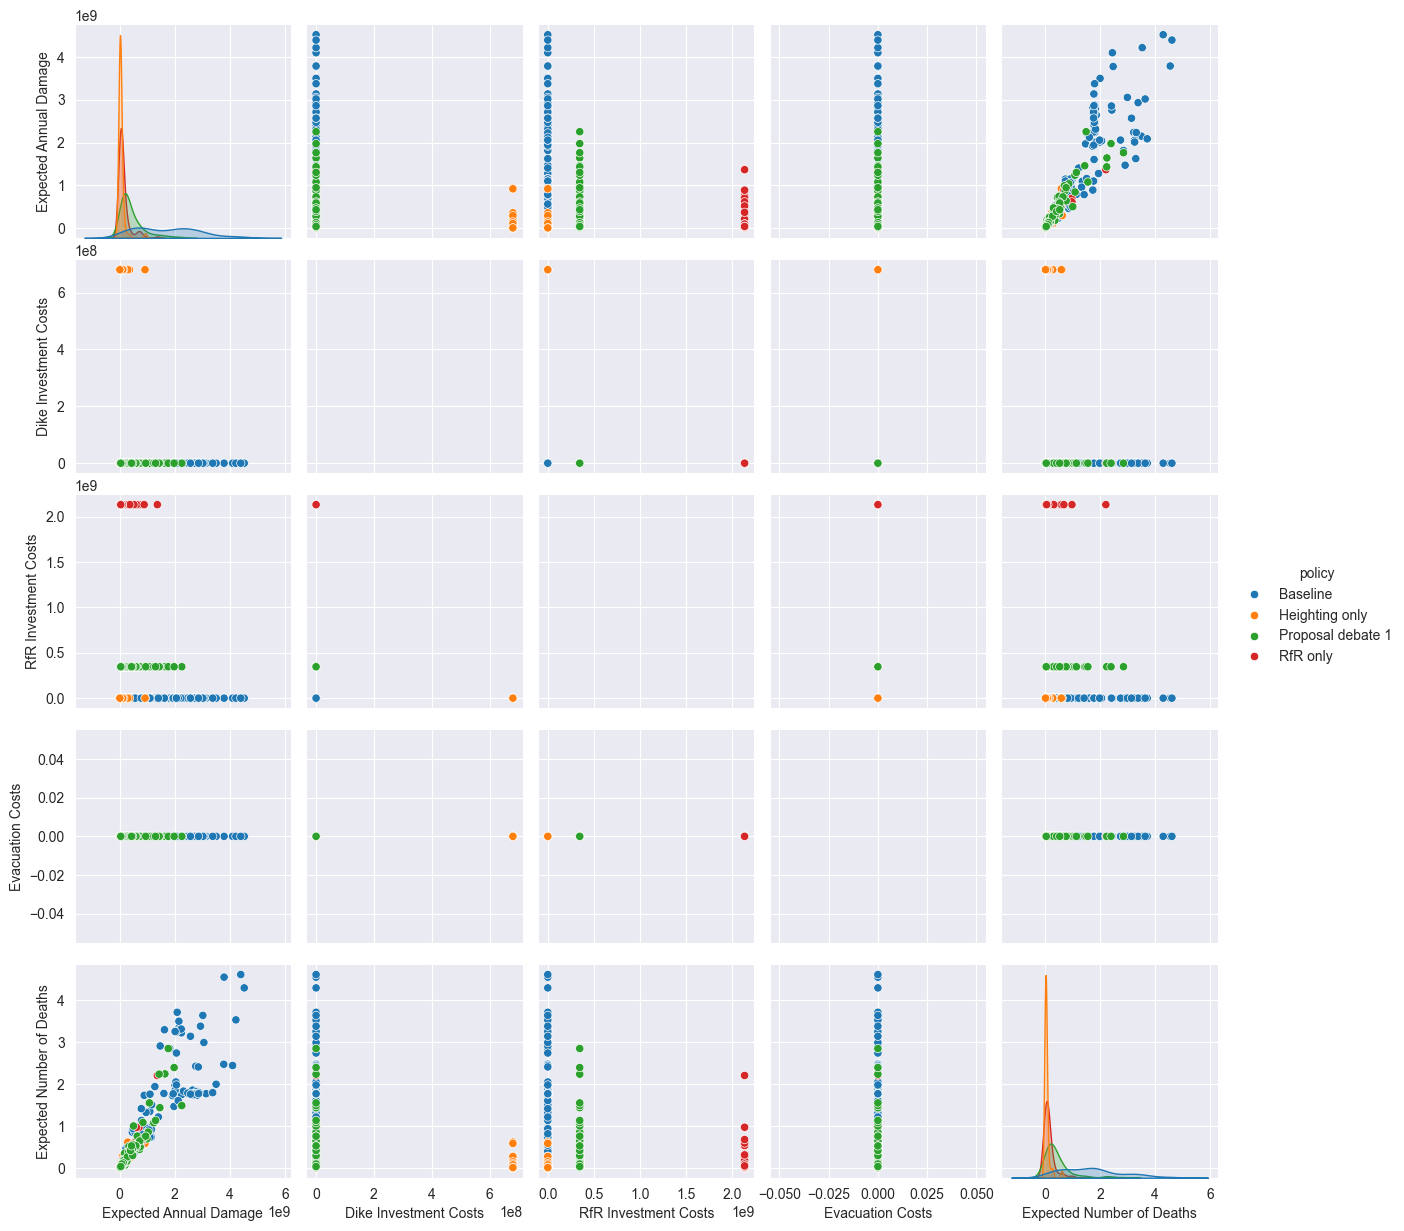

In [16]:
policies = experiments['policy']

data = pd.DataFrame.from_dict(outcomes)
data['policy'] = policies

sns.pairplot(data, hue='policy',  vars=outcomes.keys(), )
plt.show()